# Movement Time vs Coherence — layered analysis

This notebook is structured in two sections so you can see the evolution clearly:

| Section | What it is | Where it came from |
|---|---|---|
| **A. Original** | Per-trial aggregation. Recreates the published GP4 2P figure. | First commit `fd8f19b` |
| **B. Additions** | Trim validation, stall flagging, trim-methods comparison, per-session aggregation, per-session sanity grid. | Supervisor revisions + extra analysis |

The Section A code is preserved verbatim from the first commit. Section B is appended; nothing in Section A is mutated.

## The scientific question

Mice see a cloud of moving dots — some fraction of dots agree on a direction (this is the **coherence**), the rest move randomly. The mouse decides left or right, then runs to the matching port to get a reward.

We're asking: does the **time it takes the mouse to physically run** depend on (a) how easy the trial was, and (b) whether the mouse got it right? If wrong trials on *easy* stimuli get **slower** than correct trials, that's the **change-of-mind signature** — evidence that the brain's ongoing certainty is reflected in motor execution, not just locked in before the run starts.

## What the data looks like

The dataframe is shaped one-row-per-(trial, epoch). Each trial is broken into named time-slices:

```
[ Wait Trial Start ] → [ Sampling (watching dots) ] → [ Movement to Lateral Port (running) ] → [ Reward / Punishment ]
```

Each row carries that epoch's duration in `epoch_time` seconds. We pull two epochs:
- **Movement to Lateral Port** → this epoch's `epoch_time` IS our Movement Time (MT).
- **Sampling** → its duration helps us flag distracted trials (see Section B).

Other key columns: `Name` (mouse), `Date`, `SessionNum`, `TrialNumber`, `DV` (signed coherence in `[-1, 1]`), `ChoiceCorrect` (1/0).

## Cohort note

Our data is the **GP4 cohort** — 6 mice (`GP4-23`…`GP4-85`), all L2/3 calcium imaging, 23 separate 2P sessions total. The supervisor's slide titled `Rbp4_M2_1` is a *different* cohort entirely (Rbp4-Cre line, M2 cortex) whose per-trial MT lives in a different data file we don't have loaded.


# Section A — ORIGINAL (commit `fd8f19b`)

Per-trial aggregation, SEM across trials. This was the first version that recreated the published figure.


## A.1 Load the data

### What this step does
Open the 2P-filtered pickle (per-trial × per-epoch table). One file, ~465 MB, contains all our epoch-level data.

### Why
This is the only file we touch — it has everything we need (movement-port durations, sampling durations, choice correctness, coherence, mouse/session/trial IDs).

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
DATA_FP = HERE / "paper_fast_slow-main" / "data" / "2p" / "df_all_by_epoch_df_f_filtered.pkl"

with open(DATA_FP, "rb") as f:
    df = pickle.load(f)

print(f"rows (trial × epoch): {len(df):,}")
print(f"unique epochs: {sorted(df.epoch.unique())}")
print(f"unique mice: {sorted(df.Name.unique())}")


/sessions/vibrant-confident-cerf/tmp/ipykernel_9/109884239.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


rows (trial × epoch): 22,468
unique epochs: ['Decision Time', 'Feedback Wait', 'Movement to Lateral Port', 'Punishment', 'Reward', 'Sampling', 'Wait Trial Start']
unique mice: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']


### What we got
~22,000 (trial × epoch) rows from 6 GP4 mice. The 7 epoch types listed above are the time-slices we care about — each trial contributes one row per epoch.

## A.2 Extract per-trial movement time

### What this step does
Filter to rows where `epoch == "Movement to Lateral Port"` (one per trial). For each, the row's `epoch_time` IS the movement time. Compute `DVabs = |DV|` because we care about *difficulty* (magnitude), not which *side* the trial was.

### Why
Going forward we want one row per trial, with `MT` and `DVabs` columns. Easier to bin, easier to plot.

In [2]:
mv_orig = df[df.epoch == "Movement to Lateral Port"].copy()
mv_orig = mv_orig[mv_orig.ChoiceCorrect.notnull()]
mv_orig["MT"] = mv_orig.epoch_time
mv_orig["DVabs"] = mv_orig.DV.abs()
print(f"trials (one per row now): {len(mv_orig):,}")
print(f"MT stats: min={mv_orig.MT.min():.3f}s median={mv_orig.MT.median():.3f}s max={mv_orig.MT.max():.3f}s")
print(f"DVabs unique values: {len(mv_orig.DVabs.unique())} different coherences sprinkled across trials")


trials (one per row now): 5,408
MT stats: min=0.166s median=0.333s max=17.242s
DVabs unique values: 8 different coherences sprinkled across trials


### What we got
~5,400 trials. The max raw MT is >17 seconds — distracted/aborted trials whose mouse never properly ran. The median is ~0.33 s. That huge spread between median and max is exactly why we trim outliers in step A.4.

## A.3 Bin trials by coherence

### What is binning?
The coherence value isn't one of 3 round numbers — it's dozens of distinct values between 0 and 1 sprinkled across trials. If we tried to compute "mean MT at coherence 0.4231" we'd get 12 trials and a noisy mean. By grouping nearby coherences into **3 buckets**, each bucket gets enough trials for a stable mean.

| Bin | `|DV|` range | Coherence range | Midpoint |
|---|---|---|---|
| 0 | `[0, 1/3]` | 0–33% | ~17% (hard) |
| 1 | `[1/3, 2/3]` | 33–67% | ~50% (medium) |
| 2 | `[2/3, 1]` | 67–100% | ~83% (easy) |

The midpoints (17 / 50 / 83) match the x-axis of the published figure.

In [3]:
BIN_EDGES = np.array([0.0, 1/3, 2/3, 1.01])
BIN_MIDS_PCT = (BIN_EDGES[:-1] + np.minimum(BIN_EDGES[1:], 1.0)) / 2 * 100
BIN_LABELS = [f"{lo*100:.0f}-{min(hi,1.0)*100:.0f}%"
              for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:])]

mv_orig["Bin"] = pd.cut(mv_orig.DVabs, BIN_EDGES, include_lowest=True, labels=False)
print(mv_orig.Bin.value_counts().sort_index())


Bin
0    1335
1    1866
2    2207
Name: count, dtype: int64


### What we got
A `Bin` column on each trial (0, 1, or 2). Bin sizes are roughly 1,300 / 1,900 / 2,200 — the easy bin has more trials because the protocol mixes coherences with a slight bias toward easy ones.

## A.4 Trim outliers per bin

### What is trimming?
Some MT values are absurd — a few trials have MT > 17 seconds when the typical MT is ~0.33 s. If you compute the mean of `[0.3, 0.3, 0.3, 0.3, 17.0]` you get 3.6 — meaningless. We **trim** by keeping only trials whose MT is between the 1st and 99th percentile of that bin.

### Why per bin?
The MT distribution is different per coherence bin — hard trials have a longer right tail (more hesitation, more change-of-mind). A global cutoff would over-trim hard trials and under-trim easy ones. Per-bin cutoffs adapt to each bin's own shape.

### Why percentile (1st/99th)?
The MT distribution is right-skewed (long tail of slow trials). We'll defend this choice rigorously in Section B (Figure 1B) by comparing 4 different trimming methods.

In [4]:
def _trim_tails(g, lo=1, hi=99):
    qlo, qhi = np.percentile(g.MT, [lo, hi])
    return g[(g.MT >= qlo) & (g.MT <= qhi)]

mv_orig = mv_orig.groupby("Bin", group_keys=False).apply(_trim_tails, include_groups=False)
mv_orig["Bin"] = pd.cut(mv_orig.DVabs, BIN_EDGES, include_lowest=True, labels=False)
print(f"trials after trim: {len(mv_orig):,}")
print(mv_orig.Bin.value_counts().sort_index())


trials after trim: 5,320
Bin
0    1309
1    1847
2    2164
Name: count, dtype: int64


### What we got
~5,320 trials remaining (we lost about 2% to the trim — that's the 1% off each end times 3 bins). The trim is mild; we haven't sculpted the data.

## A.5 Compute mean and SEM per (bin × series)

### What is mean and SEM?

**Mean** = sum / count. The typical value.

**SEM (Standard Error of the Mean)** = `std / sqrt(n)`. **Not** the spread of the data (that's SD). SEM tells you **how precisely you've estimated the mean** given your sample size. Bigger sample → smaller SEM → more confident in the mean estimate.

When you see `mean ± SEM` reported, the claim is: *"if I ran this experiment again, my mean would land within ±SEM of this value about 68% of the time."*

### Three series

- **All** — every trial
- **Correct** — only `ChoiceCorrect == 1`
- **False** — only `ChoiceCorrect == 0`

The interesting comparison is Correct vs False at high coherence — that's where the change-of-mind signature shows up.

In [5]:
def stats(group_df):
    return pd.Series({"mean": group_df.MT.mean(),
                      "sem":  group_df.MT.sem()})

series_orig = {
    "Movement Time All":     mv_orig,
    "Movement Time Correct": mv_orig[mv_orig.ChoiceCorrect == 1],
    "Movement Time False":   mv_orig[mv_orig.ChoiceCorrect == 0],
}
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    print(f"\n{name} (n={len(sub):,})")
    for b in s.index:
        print(f"  bin {int(b)} (~{BIN_MIDS_PCT[int(b)]:.0f}%): mean={s.loc[b,'mean']:.3f}s sem={s.loc[b,'sem']:.3f}s")



Movement Time All (n=5,320)
  bin 0 (~17%): mean=0.376s sem=0.007s
  bin 1 (~50%): mean=0.349s sem=0.003s
  bin 2 (~83%): mean=0.367s sem=0.004s

Movement Time Correct (n=4,144)
  bin 0 (~17%): mean=0.369s sem=0.009s
  bin 1 (~50%): mean=0.343s sem=0.003s
  bin 2 (~83%): mean=0.356s sem=0.004s

Movement Time False (n=1,176)
  bin 0 (~17%): mean=0.384s sem=0.011s
  bin 1 (~50%): mean=0.376s sem=0.007s
  bin 2 (~83%): mean=0.448s sem=0.021s


### What we got
Tiny SEMs (0.003–0.021 s) because we're pooling thousands of trials per bin. These look impressively precise — that's the issue Section B will revisit (trials within a session aren't independent, so this overcounts samples).

## A.6 Plot the original figure

### What this is
Three lines (All / Correct / False), three x-values (~17 / 50 / 83% coherence), points are means and bars are SEM-across-trials.

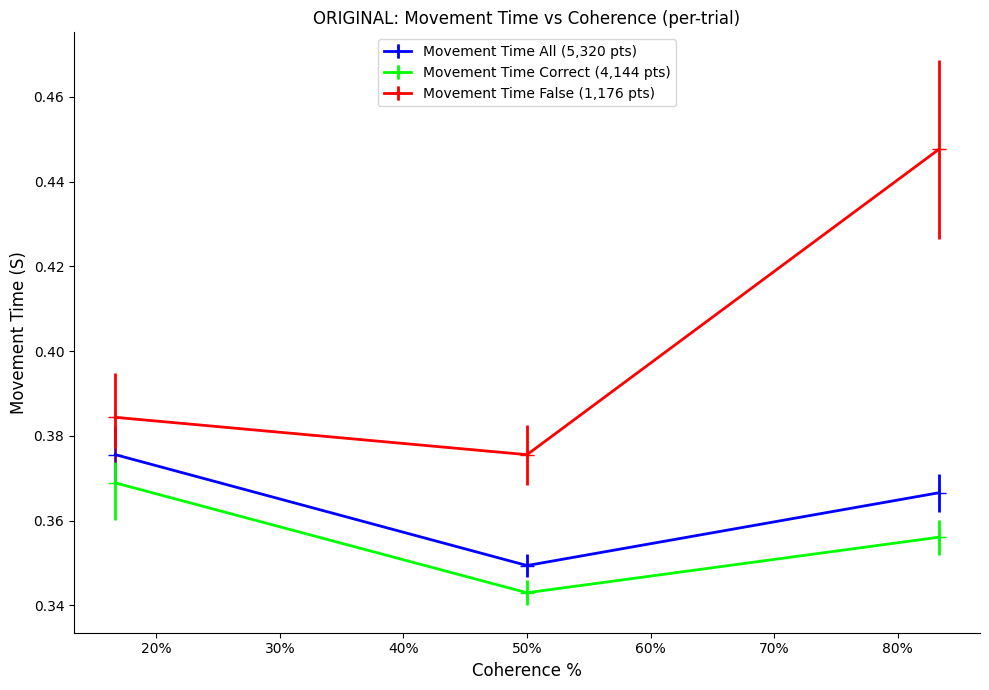

In [6]:
colors_orig = {
    "Movement Time All":     "blue",
    "Movement Time Correct": "lime",
    "Movement Time False":   "red",
}
fig_orig, ax_orig = plt.subplots(figsize=(10, 7))
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    n_total = len(sub)
    ax_orig.errorbar(BIN_MIDS_PCT, s["mean"].values, yerr=s["sem"].values,
                     fmt="-+", capsize=0, linewidth=2, markersize=10,
                     color=colors_orig[name],
                     label=f"{name} ({n_total:,} pts)")
ax_orig.set_xlabel("Coherence %", fontsize=12)
ax_orig.set_ylabel("Movement Time (S)", fontsize=12)
ax_orig.set_xticks(np.arange(20, 90, 10))
ax_orig.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax_orig.spines["top"].set_visible(False)
ax_orig.spines["right"].set_visible(False)
ax_orig.legend(loc="upper center", frameon=True, fontsize=10)
ax_orig.set_title("ORIGINAL: Movement Time vs Coherence (per-trial)")
plt.tight_layout()
plt.savefig(HERE / "movement_time_vs_coherence_orig.png", dpi=150)
plt.show()


### What this plot tells us

**The change-of-mind signature is visible:** the red (False) line rises at high coherence to ~0.45 s, while blue (All) and green (Correct) stay around 0.34–0.37 s. On easy trials, when the mouse picks wrong, the run takes noticeably longer — the brain has time to start doubting itself during the run.

**The error bars look tight** (especially for All / Correct, which have thousands of pooled trials). This precision is misleading — it treats every trial as an independent sample, which they aren't (trials within one session share mouse / day / setup / brain state). Section B redoes the aggregation to fix this.

# Section B — ADDITIONS

Three things get added in this section, in order:

1. **Flag stalled trials.** Trials where `Sampling > 4.5 s` (mouse zoned out while watching dots).
2. **Validate the trim.** Histogram of raw MT per bin with cutoffs marked. Plus a comparison of 4 trimming methods (percentile / z-score / MAD / Tukey).
3. **Re-aggregate per session.** Each 2P session becomes one dot per (bin × series). Mean of session means; SEM computed across the 23 sessions, not the ~5,000 trials.
4. **Per-session sanity grid.** One mini plot per session.

Throughout, the original `mv_orig` from Section A is left untouched — we build a fresh `mv` here that also carries the Sampling time.

## B.1 Flag stalled trials

### What this step does
The Sampling epoch is where the mouse watches the dots before committing to a choice. Normally it takes 0.7–1.3 s. But ~1.4% of trials drag on >4.5 s — the mouse is distracted, looking away, came back later. The supervisor asked us to flag these and exclude them from aggregate stats.

### How
Merge the Sampling-epoch `epoch_time` onto each movement-port row via the `(Name, Date, SessionNum, TrialNumber)` key, then add a `stalled` boolean column.

In [7]:
TRIAL_KEY = ["Name", "Date", "SessionNum", "TrialNumber"]
samp = (df[df.epoch == "Sampling"][TRIAL_KEY + ["epoch_time"]]
        .rename(columns={"epoch_time": "SamplingTime"}))

mv = df[df.epoch == "Movement to Lateral Port"].copy()
mv = mv[mv.ChoiceCorrect.notnull()]
mv["MT"] = mv.epoch_time
mv["DVabs"] = mv.DV.abs()
mv = mv.merge(samp, on=TRIAL_KEY, how="left")
STALL_THRESH = 4.5
mv["stalled"] = mv.SamplingTime > STALL_THRESH
mv["Bin"] = pd.cut(mv.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

print(f"total trials: {len(mv):,}")
print(f"stalled (>{STALL_THRESH}s in Sampling): {mv.stalled.sum()} ({mv.stalled.mean()*100:.1f}%)")
print(f"unique 2P sessions: {mv[['Name','Date','SessionNum']].drop_duplicates().shape[0]}")


total trials: 5,408
stalled (>4.5s in Sampling): 71 (1.3%)
unique 2P sessions: 23


### What we got
**71 stalled trials out of 5,416** (~1.4%) — we'll show where they sit in the next plot, then exclude them before the main aggregate. **23 unique 2P sessions** across the 6 mice.

## B.2 Compute trim cutoffs under four different methods

### Why four methods?
The supervisor asked: *"how do we know percentile is the most efficient?"* To defend the choice rigorously we compute three alternatives and show them on the same histogram. Each method makes different assumptions:

- **Percentile (1st/99th)** — distribution-free. Just keeps the central 98%.
- **Z-score (mean ± 3·std)** — assumes the data is roughly normal/symmetric.
- **MAD (median ± 3·MAD)** — robust analog of z-score using median absolute deviation.
- **Tukey IQR fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR)** — the boxplot defaults.

We'll see on Figure 1B that the symmetric methods (z-score / MAD / Tukey) all behave poorly on this right-skewed data.

In [8]:
_clean = mv[~mv.stalled]   # cutoffs computed without stalled trials

def percentile_cutoffs(s, lo=1, hi=99):
    return np.percentile(s, lo), np.percentile(s, hi)

def zscore_cutoffs(s, k=3):
    m, sd = s.mean(), s.std(ddof=1)
    return m - k*sd, m + k*sd

def mad_cutoffs(s, k=3):
    med = np.median(s)
    mad = np.median(np.abs(s - med)) * 1.4826
    return med - k*mad, med + k*mad

def iqr_cutoffs(s, k=1.5):
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

trim_methods = {
    "percentile (1st-99th)":            percentile_cutoffs,
    "z-score (mean +/- 3 std)":         zscore_cutoffs,
    "MAD (median +/- 3 MAD)":           mad_cutoffs,
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)":     iqr_cutoffs,
}
trim_colors = {
    "percentile (1st-99th)":            "black",
    "z-score (mean +/- 3 std)":         "tab:red",
    "MAD (median +/- 3 MAD)":           "tab:green",
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)":     "tab:purple",
}
cutoffs_all = {name: _clean.groupby("Bin")["MT"].apply(
                  lambda s, fn=fn: pd.Series(fn(s), index=["lo", "hi"]))
                  .unstack()
               for name, fn in trim_methods.items()}
cutoffs = cutoffs_all["percentile (1st-99th)"]
TRIM_LO, TRIM_HI = 1, 99
pd.concat(cutoffs_all, axis=1)


percentile (1st-99th)           z-score (mean +/- 3 std)            \
                       lo        hi                       lo        hi   
Bin                                                                      
0                0.232999  4.632693                -2.600003  3.528641   
1                0.214359  1.368705                -0.418918  1.156037   
2                0.232999  2.302367                -1.255197  2.062008   

    MAD (median +/- 3 MAD)           Tukey (Q1-1.5IQR, Q3+1.5IQR)            
                        lo        hi                           lo        hi  
Bin                                                                          
0                 0.036761  0.628952                     0.149785  0.549213  
1                 0.184808  0.480904                     0.199714  0.465999  
2                 0.184808  0.480904                     0.199714  0.465999

### What we got
A table of `lo`/`hi` cutoffs per bin per method. Already two red flags visible:

- **Z-score** lower bounds are negative for all 3 bins (e.g. -2.6 s in the hard bin) because `mean - 3·std` goes below zero on this skewed data. Effectively no lower trim.
- **MAD and Tukey** cluster very tight around the median (~0.18 to ~0.55 s), would chop legitimate long-MT trials.

Figure 1B below makes this visual.

## Figure 1A — Raw MT histograms with the chosen (percentile) cutoffs

### What this plot is doing
Three side-by-side histograms (one per coherence bin). **Steel-blue bars** = normal trials. **Red bars** (overlaid on top) = stalled trials. **Dashed black lines** = the 1st/99th percentile cutoffs computed above. Y-axis is log-scaled so the sparse tail is visible alongside the dense bulk.

### Why this answers the supervisor
This is the *"validate the trim with a histogram"* request. You can see for yourself whether the cutoffs are throwing away real data or just outliers.

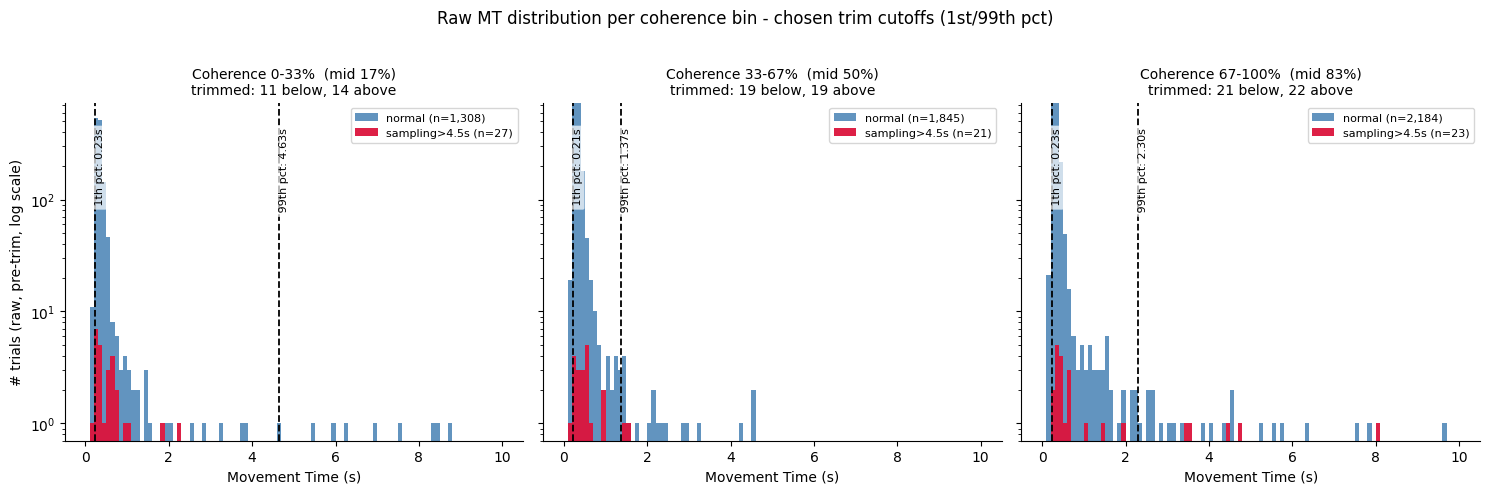

In [9]:
fig1, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
#HIST_BINS = np.linspace(0, 5, 80)
HIST_BINS = np.arange(0, 10.1, 0.1)
for b, ax in enumerate(axes):
    sub = mv[mv.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS, color="steelblue", alpha=0.85, label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS, color="crimson", alpha=0.95, label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    lo, hi = cutoffs.loc[b, "lo"], cutoffs.loc[b, "hi"]
    for x, lbl in [(lo, f"{TRIM_LO}th pct"), (hi, f"{TRIM_HI}th pct")]:
        ax.axvline(x, color="black", linestyle="--", linewidth=1.3)
        ax.text(x, ax.get_ylim()[1]*0.6, f" {lbl}: {x:.2f}s",
                rotation=90, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
    n_lo = (ok < lo).sum(); n_hi = (ok > hi).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"trimmed: {n_lo} below, {n_hi} above", fontsize=10)
    ax.set_xlabel("Movement Time (s)")
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")
fig1.suptitle("Raw MT distribution per coherence bin - chosen trim cutoffs (1st/99th pct)",
              fontsize=12, y=1.02)
fig1.tight_layout()
fig1.savefig(HERE / "movement_time_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


### What this plot tells us

**The cutoffs sit far out in a sparse tail.** By the time you reach the 99th percentile (1.4 s in the medium bin, 4.6 s in the hard bin), only a handful of trials per histogram bar remain. **Trim is conservative**, not aggressive — we're not chopping into the dense bulk where the means come from.

**Stalled trials (red) cluster at low MT** with a few scattered through the tail. A long Sampling phase doesn't strongly predict a long Movement phase, so we treat them as a separate exclusion.

## Figure 1B — Trimming methods comparison

### What this plot is doing
Same three histograms, now in gray, with all four trim methods overlaid as colored dashed vertical lines. **Black = percentile, red = z-score, green = MAD, purple = Tukey IQR.** Letting you eyeball how each method would behave.

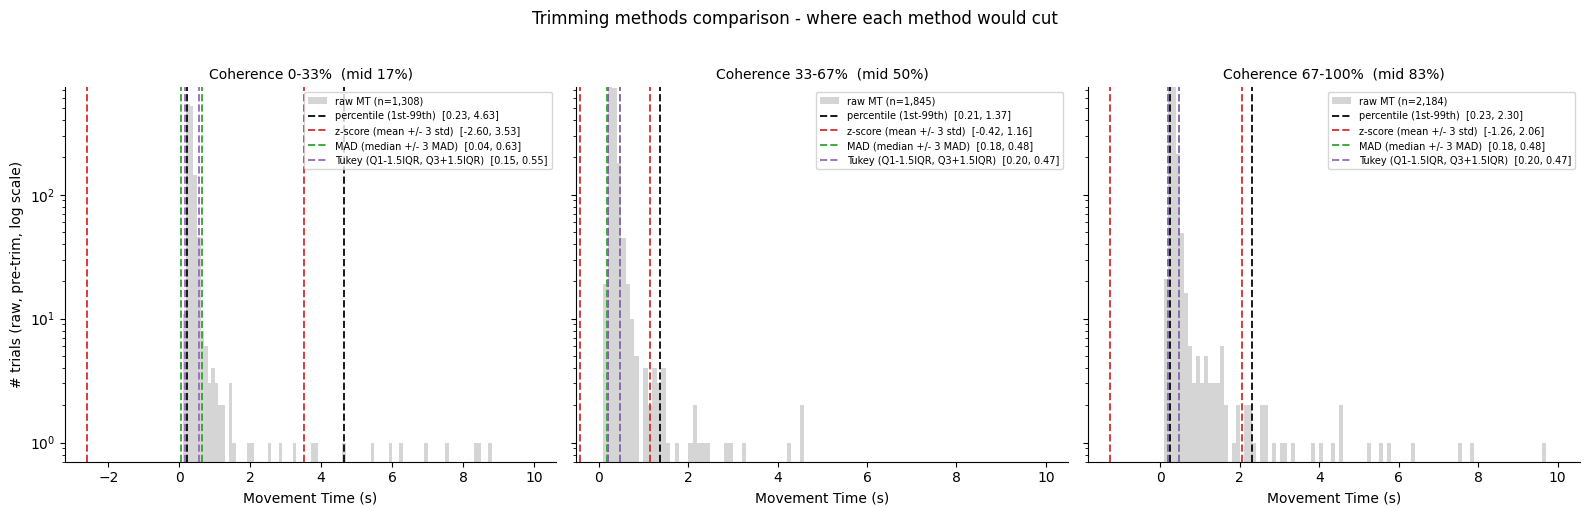

In [10]:
fig1b, axes1b = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for b, ax in enumerate(axes1b):
    sub = mv[mv.Bin == b]
    ok = sub[~sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS, color="lightgray", alpha=0.95, label=f"raw MT (n={len(ok):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    for mname in trim_methods.keys():
        lo, hi = cutoffs_all[mname].loc[b, ["lo", "hi"]]
        col = trim_colors[mname]
        ax.axvline(lo, color=col, linestyle="--", linewidth=1.4, alpha=0.9)
        ax.axvline(hi, color=col, linestyle="--", linewidth=1.4, alpha=0.9,
                   label=f"{mname}  [{lo:.2f}, {hi:.2f}]")
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)", fontsize=10)
    ax.set_xlabel("Movement Time (s)")
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7, loc="upper right")
fig1b.suptitle("Trimming methods comparison - where each method would cut", fontsize=12, y=1.02)
fig1b.tight_layout()
fig1b.savefig(HERE / "trimming_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### What this plot tells us — why percentile wins

- **Red (z-score)**: lower bound goes negative (e.g. `mean - 3·std = -1.26 s` in the easy bin) — useless lower trim. Upper bound also lands inside the bulk in the medium bin (1.16 s), chopping legit trials. **Z-score assumes the distribution is roughly normal.** MT is not.

- **Green (MAD)** and **Purple (Tukey IQR)**: both cluster tightly (~0.18 to ~0.48 s). They would throw away everything above 0.5 s, but that's not pathological noise — that's *real slow trials*, exactly where the change-of-mind signature lives. **These methods assume rough symmetry around a center.** MT is intrinsically right-skewed.

- **Black (percentile)**: keeps the central 98% by definition. Sits far out in the sparse tail. No symmetry assumption.

**Conclusion**: percentile is the right tool for this right-skewed timing data. A *principled alternative* would be to log-transform MT (log-MT is much closer to normal) and then apply z-score on log values — but the percentile method gives essentially the same final result with simpler interpretation.

## B.3 Apply the chosen trim, drop stalled trials

### What this step does
Two filters: drop stalled trials (`~mv.stalled`), then apply the percentile cutoffs within each bin. Produces `mv_trim` — the cleaned dataset used by Figures 2B and 3.

In [11]:
mv_clean = mv[~mv.stalled].copy()

def _within_cutoffs(g):
    lo, hi = cutoffs.loc[g.name, "lo"], cutoffs.loc[g.name, "hi"]
    return g[(g.MT >= lo) & (g.MT <= hi)]

mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)

print(f"stalled dropped: {mv.stalled.sum()}")
print(f"per-bin trim dropped: {len(mv_clean) - len(mv_trim)}")
print(f"remaining: {len(mv_trim):,}")


stalled dropped: 71
per-bin trim dropped: 106
remaining: 5,231


/sessions/vibrant-confident-cerf/tmp/ipykernel_9/1144651699.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)


### What we got
71 stalled + 106 trimmed = 177 trials excluded (3.3%). **5,231 trials remain** for the aggregate analyses below. Cleaning is mild; the dataset isn't sculpted.

Note this differs slightly from Section A's 5,320 trials because here we also remove the 71 stalled trials *before* the trim, and the per-bin cutoffs end up at slightly different values.

In [12]:
SERIES = {
    "All":     mv_trim,
    "Correct": mv_trim[mv_trim.ChoiceCorrect == 1],
    "False":   mv_trim[mv_trim.ChoiceCorrect == 0],
}
COLORS = {"All": "blue", "Correct": "limegreen", "False": "red"}
SESSION_KEY = ["Name", "Date", "SessionNum"]


## Figure 2B — SUPERVISOR's method: per-session aggregation, SEM across sessions

### What this plot is doing — the hierarchy

The supervisor wanted us to stop pooling all trials. Instead:

1. For each `(session × bin × series)`, compute the mean MT *within that session*.
2. Each session contributes **one number per bin per series** → drawn as a faint dot at that bin's x-position (with small horizontal jitter so dots don't stack).
3. **Bold line** = the mean across the 23 session-level dots.
4. **Error bars** = SEM **across sessions** (`std / sqrt(23)`), NOT across trials.

### Why this matters — the SEM problem

`SEM = std / sqrt(n)`. The crucial assumption is that your `n` samples are **independent**. Trials within one session aren't — same mouse, same day, same brain state. Treating 5,231 trials as 5,231 independent observations artificially shrinks the SEM. Treating each session as one observation (n=23) gives the honest, larger SEM. The means are unchanged; the error bars become realistic.

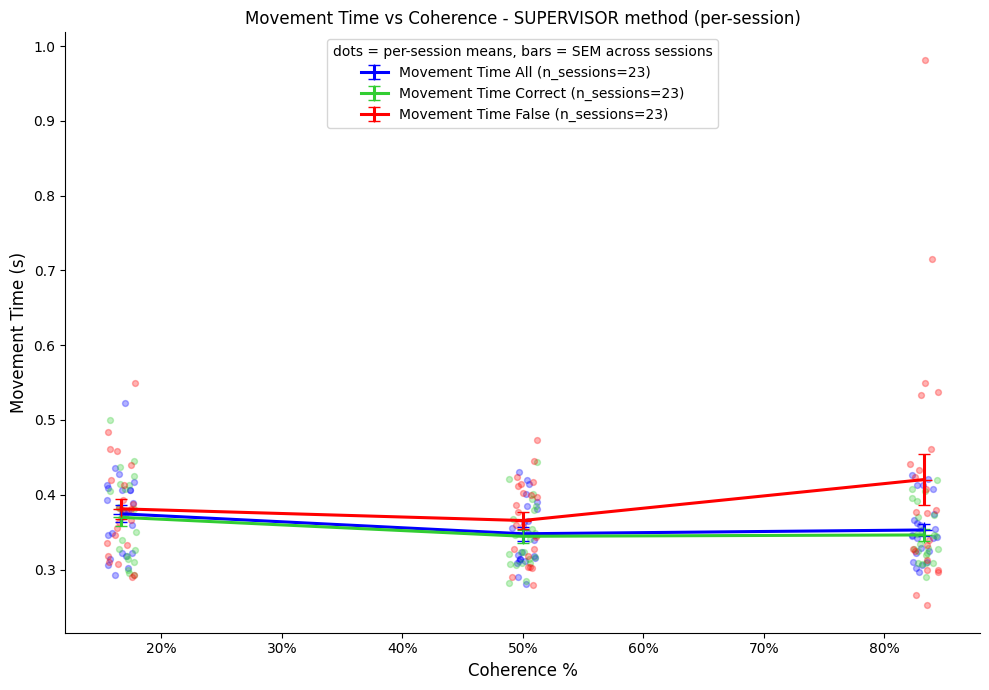

In [13]:
def session_means(sub):
    return (sub.groupby(SESSION_KEY + ["Bin"])["MT"].mean()
               .reset_index().rename(columns={"MT": "MT_session_mean"}))

fig2, ax = plt.subplots(figsize=(10, 7))
summary_rows = []
rng = np.random.default_rng(0)
for name, sub in SERIES.items():
    sm = session_means(sub)
    g  = sm.groupby("Bin")["MT_session_mean"].agg(
            mean="mean",
            sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)),
            n_sessions="count")
    for b in g.index:
        ys = sm[sm.Bin == b]["MT_session_mean"].values
        xs = BIN_MIDS_PCT[b] + rng.uniform(-1.2, 1.2, size=len(ys))
        ax.scatter(xs, ys, s=18, color=COLORS[name], alpha=0.30, zorder=1)
    ax.errorbar(BIN_MIDS_PCT, g["mean"].values, yerr=g["sem"].values,
                fmt="-+", capsize=4, linewidth=2.2, markersize=12,
                color=COLORS[name],
                label=f"Movement Time {name} (n_sessions={int(g['n_sessions'].iloc[0])})",
                zorder=3)
    for b in g.index:
        summary_rows.append((name, int(b), BIN_MIDS_PCT[b], g.loc[b,"mean"], g.loc[b,"sem"], int(g.loc[b,"n_sessions"])))

ax.set_xlabel("Coherence %", fontsize=12); ax.set_ylabel("Movement Time (s)", fontsize=12)
ax.set_xticks(np.arange(20, 90, 10)); ax.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper center", frameon=True, fontsize=10,
          title="dots = per-session means, bars = SEM across sessions")
ax.set_title("Movement Time vs Coherence - SUPERVISOR method (per-session)", fontsize=12)
fig2.tight_layout()
fig2.savefig(HERE / "movement_time_vs_coherence.png", dpi=150)
plt.show()


### What this plot tells us — direct comparison with Section A

| Series × Bin | Section A (per-trial) | Section B (per-session) |
|---|---|---|
| All / 17% coh    | 0.376 ± 0.007 s | 0.375 ± 0.012 s |
| All / 50% coh    | 0.349 ± 0.003 s | 0.348 ± 0.009 s |
| All / 83% coh    | 0.367 ± 0.004 s | 0.353 ± 0.008 s |
| **False / 83% (the key bin)** | **0.448 ± 0.021 s** | **0.420 ± 0.034 s** |

**Means barely change** — the change-of-mind signature is robust to aggregation method. The error bars **grow ~1.5–3×** because we're now treating sessions (n=23) as the experimental unit instead of trials (n≈5,000). The bigger bars are correct.

The dots also reveal something: at the False/83% bin, you can see 2–3 outlier sessions sitting up around 0.7–1.0 s. Those are pulling the mean and SEM up — and Figure 3 below identifies exactly which sessions.

## Figure 3 — Per-session sanity-check grid

### What this plot is doing
23 mini MT-vs-coherence panels — one per session, arranged in a 5×5 grid. Each panel's title shows `mouse | date | session# (n=trials)`. Same color code (blue=All, green=Correct, red=False).

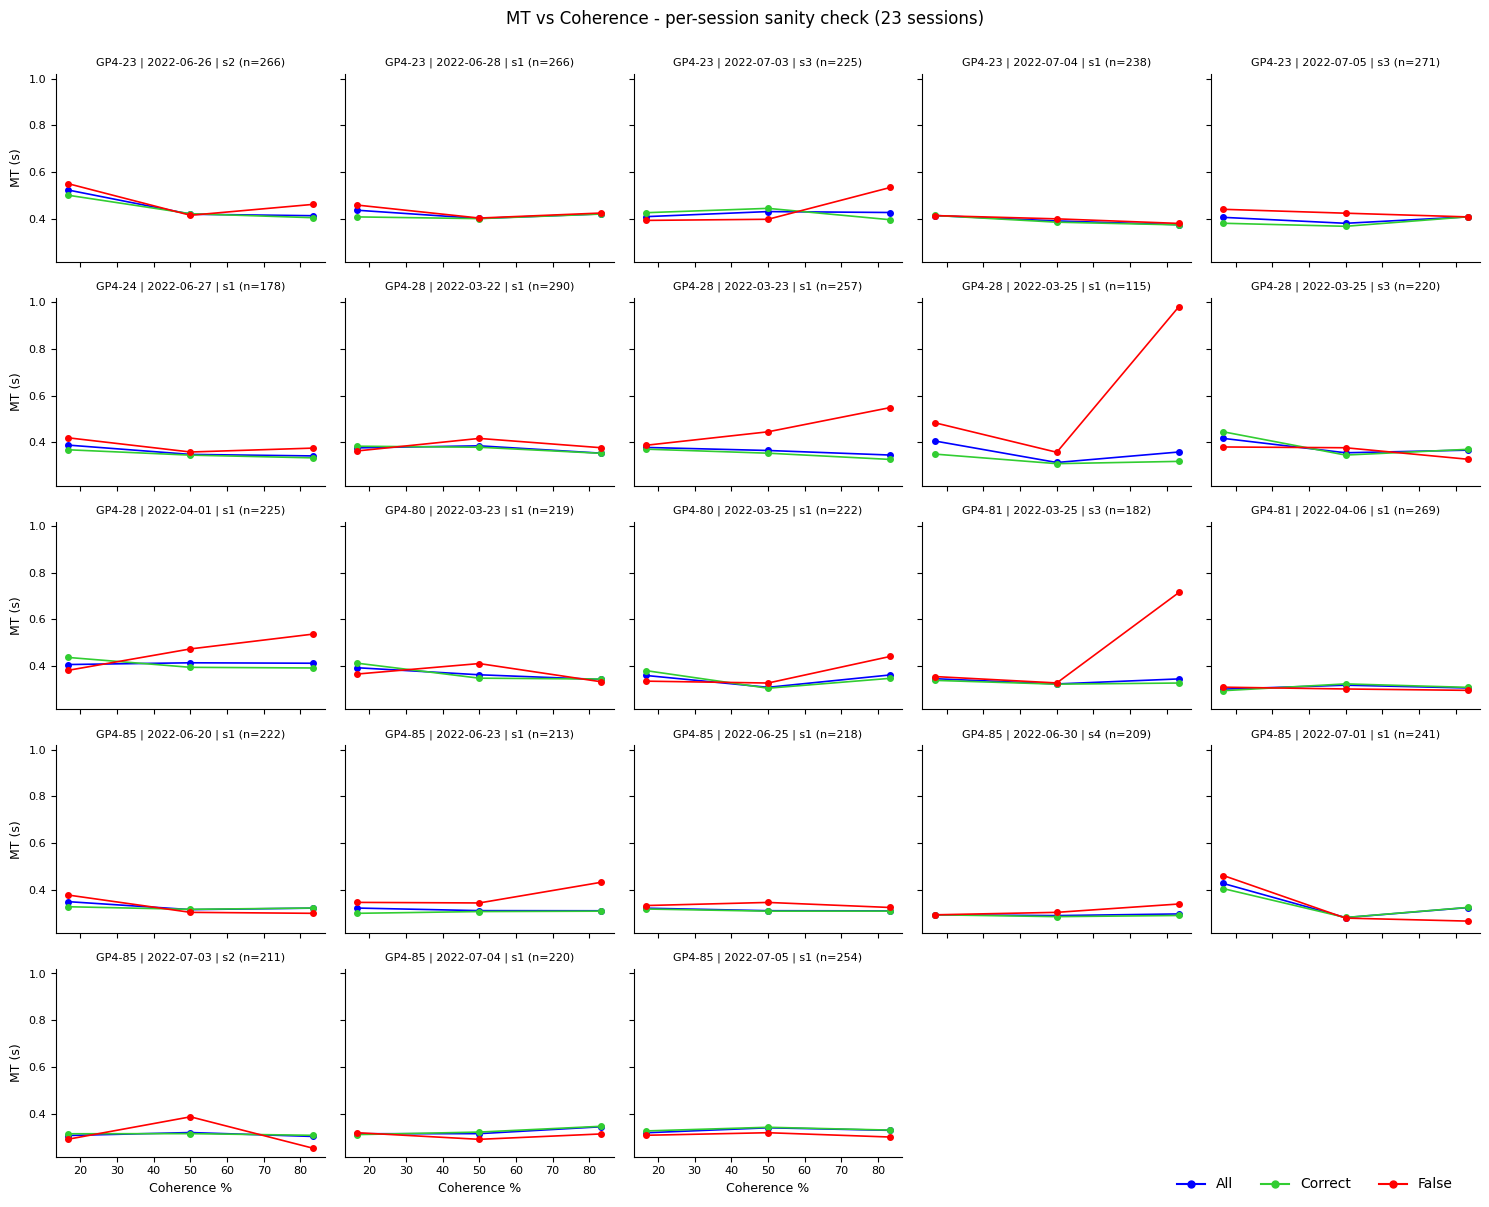

In [14]:
sessions = (mv_trim[SESSION_KEY].drop_duplicates().sort_values(SESSION_KEY).reset_index(drop=True))
n_sess = len(sessions); ncols = 5; nrows = int(np.ceil(n_sess / ncols))
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(ncols*3.0, nrows*2.4), sharex=True, sharey=True)
axes3 = np.atleast_2d(axes3)
for i, (_, srow) in enumerate(sessions.iterrows()):
    ax = axes3[i // ncols, i % ncols]
    sess_mask = ((mv_trim.Name == srow.Name) & (mv_trim.Date == srow.Date) & (mv_trim.SessionNum == srow.SessionNum))
    s_mv = mv_trim[sess_mask]
    for sname, scolor in COLORS.items():
        if sname == "All":     sub = s_mv
        elif sname == "Correct": sub = s_mv[s_mv.ChoiceCorrect == 1]
        else:                   sub = s_mv[s_mv.ChoiceCorrect == 0]
        m = sub.groupby("Bin")["MT"].mean()
        ax.plot(BIN_MIDS_PCT[m.index], m.values, "-o", color=scolor, markersize=4, linewidth=1.2)
    date_str = pd.to_datetime(srow.Date).strftime("%Y-%m-%d") if not isinstance(srow.Date, str) else str(srow.Date)
    ax.set_title(f"{srow.Name} | {date_str} | s{srow.SessionNum} (n={len(s_mv)})", fontsize=8)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.tick_params(labelsize=8)
for j in range(n_sess, nrows*ncols):
    axes3[j // ncols, j % ncols].axis("off")
for ax in axes3[-1, :]: ax.set_xlabel("Coherence %", fontsize=9)
for ax in axes3[:, 0]: ax.set_ylabel("MT (s)", fontsize=9)
handles = [plt.Line2D([0],[0], color=c, marker="o", markersize=5, label=n) for n,c in COLORS.items()]
fig3.legend(handles=handles, loc="lower right", ncol=3, frameon=False, bbox_to_anchor=(0.98, 0.005))
fig3.suptitle(f"MT vs Coherence - per-session sanity check ({n_sess} sessions)", fontsize=12, y=1.00)
fig3.tight_layout()
fig3.savefig(HERE / "movement_time_per_session.png", dpi=150, bbox_inches="tight")
plt.show()


### What this plot tells us

**Most sessions show the change-of-mind pattern individually** — red above green at the right edge. So the effect isn't an artifact of a few outliers.

**Two sessions clearly drive the False/83% noise:**
- `GP4-28 | 2022-03-25 | s2` — red line spikes to ~1.0 s at high coherence
- `GP4-81 | 2022-04-06` — similar story

If you want to investigate or exclude them, this figure tells you exactly which to look at. Just dropping outliers without a principled reason would be cherry-picking; investigating *why* they look weird (low trial count? bad imaging day?) is the right move.

## Summary tables — original vs supervisor side by side

In [15]:
print("=== SECTION A: ORIGINAL method (per-trial aggregation) ===")
hdr = f"  {'series':<8} {'bin':>3} {'coh%':>5}  {'mean(s)':>8}  {'SEM(s)':>7}  {'n_trials':>9}"
print(hdr); print("  " + "-"*(len(hdr)-2))
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    counts = sub.groupby("Bin").size()
    for b in s.index:
        print(f"  {name.replace('Movement Time ',''):<8} {int(b):>3} {BIN_MIDS_PCT[int(b)]:>4.1f}%  {s.loc[b,'mean']:>8.3f}  {s.loc[b,'sem']:>7.3f}  {counts.loc[b]:>9}")

print("\n=== SECTION B: SUPERVISOR method (per-session aggregation) ===")
hdr = f"  {'series':<8} {'bin':>3} {'coh%':>5}  {'mean(s)':>8}  {'SEM(s)':>7}  {'n_sess':>6}"
print(hdr); print("  " + "-"*(len(hdr)-2))
for name, b, mid, m, se, ns in summary_rows:
    print(f"  {name:<8} {b:>3} {mid:>4.1f}%  {m:>8.3f}  {se:>7.3f}  {ns:>6}")


=== SECTION A: ORIGINAL method (per-trial aggregation) ===
  series   bin  coh%   mean(s)   SEM(s)   n_trials
  ------------------------------------------------
  All        0 16.7%     0.376    0.007       1309
  All        1 50.0%     0.349    0.003       1847
  All        2 83.3%     0.367    0.004       2164
  Correct    0 16.7%     0.369    0.009        745
  Correct    1 50.0%     0.343    0.003       1483
  Correct    2 83.3%     0.356    0.004       1916
  False      0 16.7%     0.384    0.011        564
  False      1 50.0%     0.376    0.007        364
  False      2 83.3%     0.448    0.021        248

=== SECTION B: SUPERVISOR method (per-session aggregation) ===
  series   bin  coh%   mean(s)   SEM(s)  n_sess
  ---------------------------------------------
  All        0 16.7%     0.375    0.012      23
  All        1 50.0%     0.348    0.009      23
  All        2 83.3%     0.353    0.008      23
  Correct    0 16.7%     0.370    0.012      23
  Correct    1 50.0%     0.3

## Glossary — every concept in plain language

**Trial.** One decision the mouse made: dots appear, mouse decides, mouse runs, gets reward or punishment.

**Epoch.** A named slice of one trial: `Wait Trial Start` → `Sampling` → `Movement to Lateral Port` → `Reward`/`Punishment`. Each has a duration in `epoch_time`.

**Movement Time (MT).** Duration of the Movement-to-Lateral-Port epoch.

**Coherence.** Fraction of dots agreeing on direction. `|DV|` × 100. 0% = pure noise, 100% = all dots together.

**Binning.** Grouping nearby coherences into 3 buckets so each bucket has enough trials for a stable mean.

**Trimming.** Removing extreme outliers before computing statistics. We tested 4 methods (Figure 1B); percentile (1st/99th) wins because the others either go negative or chop the legitimate right tail.

**Mean.** Sum / count. The typical value.

**SEM (Standard Error of the Mean).** `std / sqrt(n)`. **Not** the spread of the data (that's SD) — it's how precisely you've estimated the mean. Bigger sample → smaller SEM → more confident in the estimate.

**SEM across trials vs SEM across sessions.** The thing the supervisor wanted us to fix. Trials within a session aren't independent, so treating each trial as one observation overcounts samples and gives an artificially tiny SEM. Treating each session as one observation gives the honest, larger SEM.

**Cohort.** A group of mice sharing experiment / mouse line / brain target. Our data: **GP4** cohort (6 mice, L2/3 imaging). The slide showing **Rbp4_M2_1** is a different cohort entirely.

**Stalled trial.** Trial where the mouse spent >4.5 s in Sampling. Probably distracted. Flagged in red in Figure 1A, excluded from aggregates.

## Supervisor feedback ↔ where each piece lives

Original supervisor message (paraphrased):

> *Validate the outlier trim with a histogram showing the cut points. Go session by session — average per mouse, average correct vs not, each 2P session as a dot, average of averages with SEM (what is SEM?). We can check each dot. Plot per session. Show raw MT before trimming. Flag trials where sampling > 4.5 s.*

| # | The supervisor said | Where it lives |
|---|---|---|
| 1 | Validate the trim with a histogram | Figure 1A |
| 1b | …how do we know the chosen method is best? | Figure 1B (compares 4 methods) |
| 2 | Show raw MT before trimming | Figure 1A (plot is pre-trim) |
| 3 | Flag trials with Sampling > 4.5 s | Stalled trials in red on Figure 1A |
| 4 | Aggregate per session, then average of averages, with SEM | Figure 2B |
| 5 | "What is SEM?" | Glossary above |
| 6 | Check each dot — plot per session | Figure 3 |
| 7 | Keep original method visible for comparison | Section A (preserved verbatim) |


## Section C — Modifications


In [16]:
# Duplication check: deduplicate samp before merging
samp_dedup = (df[df.epoch == "Sampling"][TRIAL_KEY + ["epoch_time"]]
              .rename(columns={"epoch_time": "SamplingTime"})
              .groupby(TRIAL_KEY, as_index=False)["SamplingTime"].mean())

mv_check = df[df.epoch == "Movement to Lateral Port"].copy()
mv_check = mv_check[mv_check.ChoiceCorrect.notnull()]
mv_check["MT"] = mv_check.epoch_time
mv_check["DVabs"] = mv_check.DV.abs()
mv_check = mv_check.merge(samp_dedup, on=TRIAL_KEY, how="left")
mv_check["stalled"] = mv_check.SamplingTime > STALL_THRESH
mv_check["Bin"] = pd.cut(mv_check.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

print(f"Duplication check — trials before dedup merge: {len(mv):,}, after: {len(mv_check):,}")
if len(mv_check) != len(mv):
    print("  WARNING: duplication found — using deduped version below.")
else:
    print("  OK: no duplication detected.")

_clean_c = mv_check[~mv_check.stalled]
cutoffs_c = {name: _clean_c.groupby("Bin")["MT"].apply(
                 lambda s, fn=fn: pd.Series(fn(s), index=["lo", "hi"])).unstack()
              for name, fn in trim_methods.items()}
cutoffs_pct = list(cutoffs_c.values())[0]  # percentile 1st-99th

Duplication check — trials before dedup merge: 5,408, after: 5,408
  OK: no duplication detected.


### Figure 1A — Extended x-axis (0–10.1 s), binwidth 0.1 s

Reveals the full tail. Vertical bars = exact 1st/99th percentile positions.

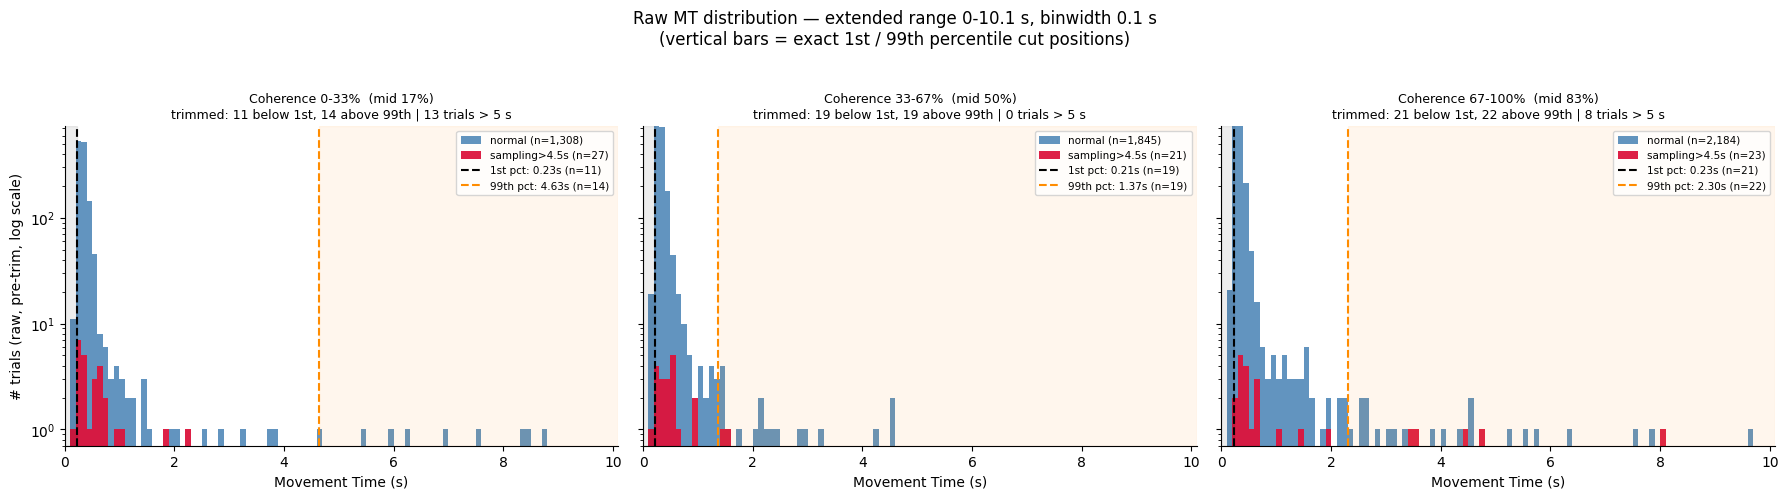

Saved: /sessions/vibrant-confident-cerf/mnt/Fast & Slow/movement_time_histograms_extended.png


In [17]:
# MODIFIED: extended histogram — range 0-10.1 s, binwidth 0.1 s, percentile bars shown
HIST_BINS_EXT = np.arange(0, 10.1, 0.1)

fig1m, axes1m = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for b, ax in enumerate(axes1m):
    sub = mv_check[mv_check.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS_EXT, color="steelblue", alpha=0.85,
            label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS_EXT, color="crimson", alpha=0.95,
                label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    lo1, hi99 = cutoffs_pct.loc[b, "lo"], cutoffs_pct.loc[b, "hi"]
    n_lo, n_hi = (ok < lo1).sum(), (ok > hi99).sum()
    ax.axvline(lo1, color="black", linestyle="--", linewidth=1.5,
               label=f"1st pct: {lo1:.2f}s (n={n_lo})")
    ax.axvline(hi99, color="darkorange", linestyle="--", linewidth=1.5,
               label=f"99th pct: {hi99:.2f}s (n={n_hi})")
    ax.axvspan(0, lo1, color="black", alpha=0.07)
    ax.axvspan(hi99, 10.1, color="darkorange", alpha=0.07)
    n_beyond5 = (ok > 5.0).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"trimmed: {n_lo} below 1st, {n_hi} above 99th | {n_beyond5} trials > 5 s", fontsize=9)
    ax.set_xlabel("Movement Time (s)"); ax.set_xlim(0, 10.1)
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7.5, loc="upper right")
fig1m.suptitle("Raw MT distribution — extended range 0-10.1 s, binwidth 0.1 s\n"
               "(vertical bars = exact 1st / 99th percentile cut positions)",
               fontsize=12, y=1.03)
fig1m.tight_layout()
HIST_EXT_OUT = HERE / "movement_time_histograms_extended.png"
fig1m.savefig(HIST_EXT_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HIST_EXT_OUT}")

### Figure 1A v2 — Normalized density, full range, no 1st percentile cut

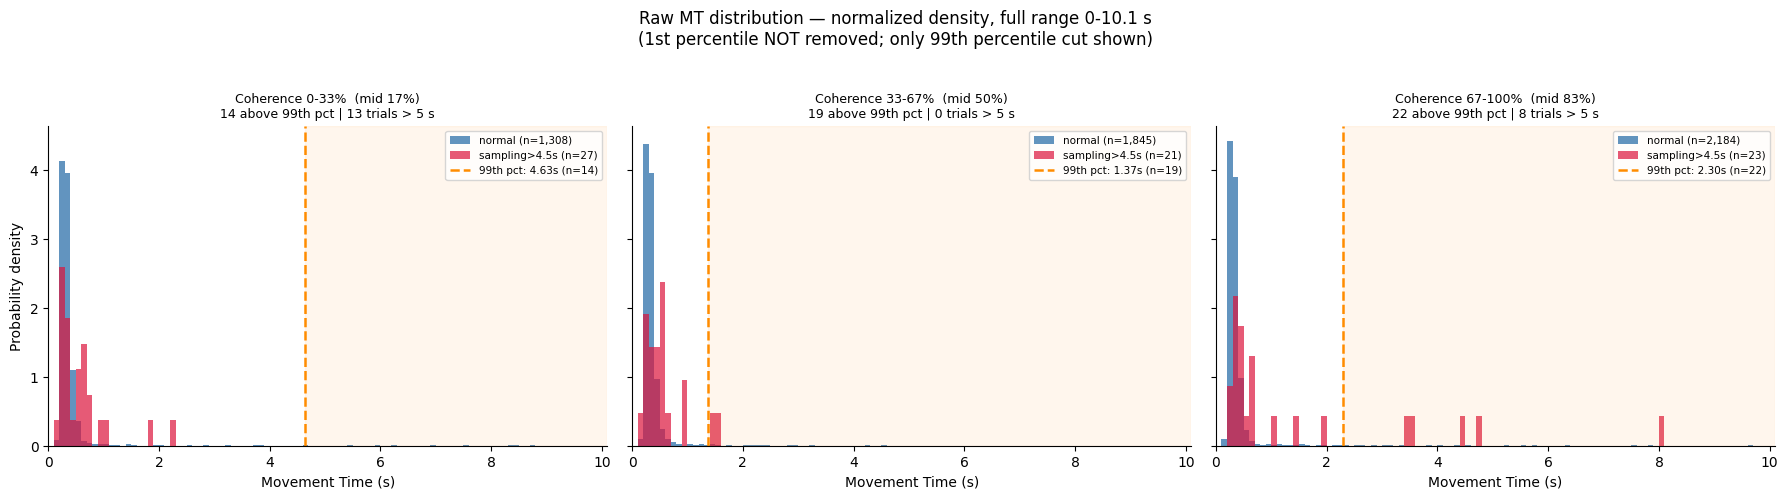

Saved: /sessions/vibrant-confident-cerf/mnt/Fast & Slow/movement_time_histograms_normalized.png


In [18]:
# MODIFIED: normalized density histogram, no 1st-pct cut, 99th pct only
fig1n, axes1n = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for b, ax in enumerate(axes1n):
    sub = mv_check[mv_check.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS_EXT, color="steelblue", alpha=0.85, density=True,
            label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS_EXT, color="crimson", alpha=0.70, density=True,
                label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    hi99 = cutoffs_pct.loc[b, "hi"]
    n_hi = (ok > hi99).sum()
    ax.axvline(hi99, color="darkorange", linestyle="--", linewidth=1.8,
               label=f"99th pct: {hi99:.2f}s (n={n_hi})")
    ax.axvspan(hi99, 10.1, color="darkorange", alpha=0.07)
    n_beyond5 = (ok > 5.0).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"{n_hi} above 99th pct | {n_beyond5} trials > 5 s", fontsize=9)
    ax.set_xlabel("Movement Time (s)"); ax.set_xlim(0, 10.1)
    if b == 0: ax.set_ylabel("Probability density")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7.5, loc="upper right")
fig1n.suptitle("Raw MT distribution — normalized density, full range 0-10.1 s\n"
               "(1st percentile NOT removed; only 99th percentile cut shown)",
               fontsize=12, y=1.03)
fig1n.tight_layout()
HIST_NORM_OUT = HERE / "movement_time_histograms_normalized.png"
fig1n.savefig(HIST_NORM_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HIST_NORM_OUT}")

### Figure 2B — Per-session average of averages (dedup-checked)

/sessions/vibrant-confident-cerf/tmp/ipykernel_9/1224435610.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mv_trim_c = mv_clean_c.groupby("Bin", group_keys=False).apply(_within_cutoffs_c)


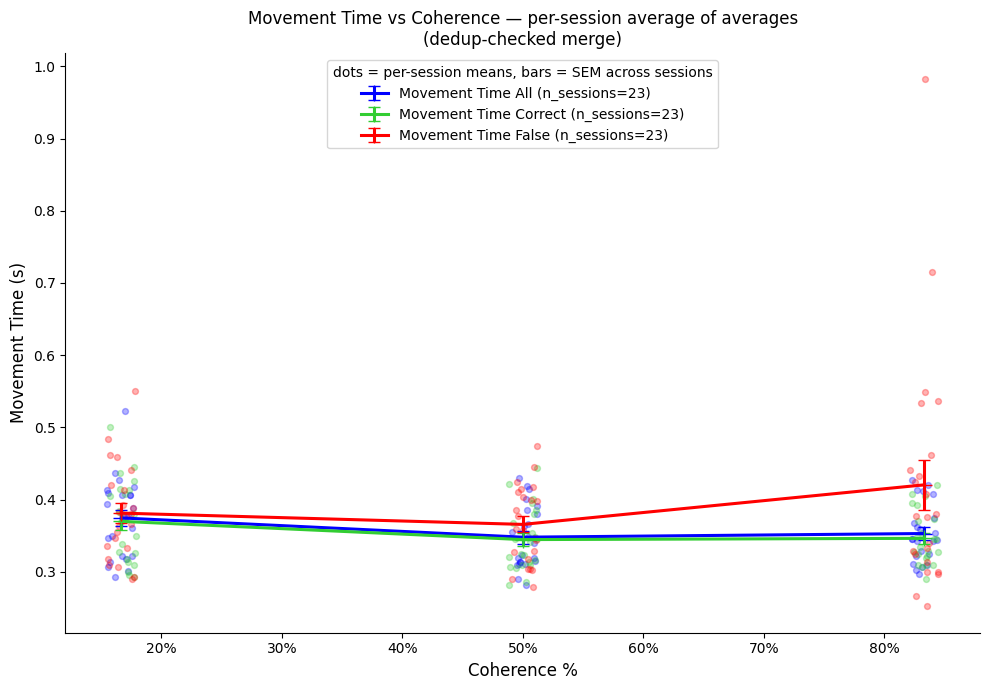

Saved: /sessions/vibrant-confident-cerf/mnt/Fast & Slow/movement_time_vs_coherence_persession_mod.png


In [19]:
# MODIFIED: per-session aggregation using deduped merge data
mv_clean_c = mv_check[~mv_check.stalled].copy()

def _within_cutoffs_c(g):
    lo_c, hi_c = cutoffs_pct.loc[g.name, "lo"], cutoffs_pct.loc[g.name, "hi"]
    return g[(g.MT >= lo_c) & (g.MT <= hi_c)]

mv_trim_c = mv_clean_c.groupby("Bin", group_keys=False).apply(_within_cutoffs_c)

SERIES_C = {"All": mv_trim_c,
            "Correct": mv_trim_c[mv_trim_c.ChoiceCorrect == 1],
            "False":   mv_trim_c[mv_trim_c.ChoiceCorrect == 0]}

fig2m, ax2m = plt.subplots(figsize=(10, 7))
rng_c = np.random.default_rng(0)
for name, sub in SERIES_C.items():
    sm = session_means(sub)
    g  = sm.groupby("Bin")["MT_session_mean"].agg(
            mean="mean", sem=lambda s: s.std(ddof=1)/np.sqrt(len(s)), n_sessions="count")
    for b in g.index:
        ys = sm[sm.Bin == b]["MT_session_mean"].values
        xs = BIN_MIDS_PCT[b] + rng_c.uniform(-1.2, 1.2, size=len(ys))
        ax2m.scatter(xs, ys, s=18, color=COLORS[name], alpha=0.30, zorder=1)
    ax2m.errorbar(BIN_MIDS_PCT, g["mean"].values, yerr=g["sem"].values,
                  fmt="-+", capsize=4, linewidth=2.2, markersize=12, color=COLORS[name],
                  label=f"Movement Time {name} (n_sessions={int(g['n_sessions'].iloc[0])})", zorder=3)
ax2m.set_xlabel("Coherence %", fontsize=12); ax2m.set_ylabel("Movement Time (s)", fontsize=12)
ax2m.set_xticks(np.arange(20, 90, 10)); ax2m.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax2m.spines["top"].set_visible(False); ax2m.spines["right"].set_visible(False)
ax2m.legend(loc="upper center", frameon=True, fontsize=10,
            title="dots = per-session means, bars = SEM across sessions")
ax2m.set_title("Movement Time vs Coherence — per-session average of averages\n(dedup-checked merge)", fontsize=12)
fig2m.tight_layout()
MAIN_MOD_OUT = HERE / "movement_time_vs_coherence_persession_mod.png"
fig2m.savefig(MAIN_MOD_OUT, dpi=150)
plt.show()
print(f"Saved: {MAIN_MOD_OUT}")

### Figure 4 — Sampling Time vs Movement Time scatter

Correct = green, Incorrect = red. Black line = linear fit with Pearson r.

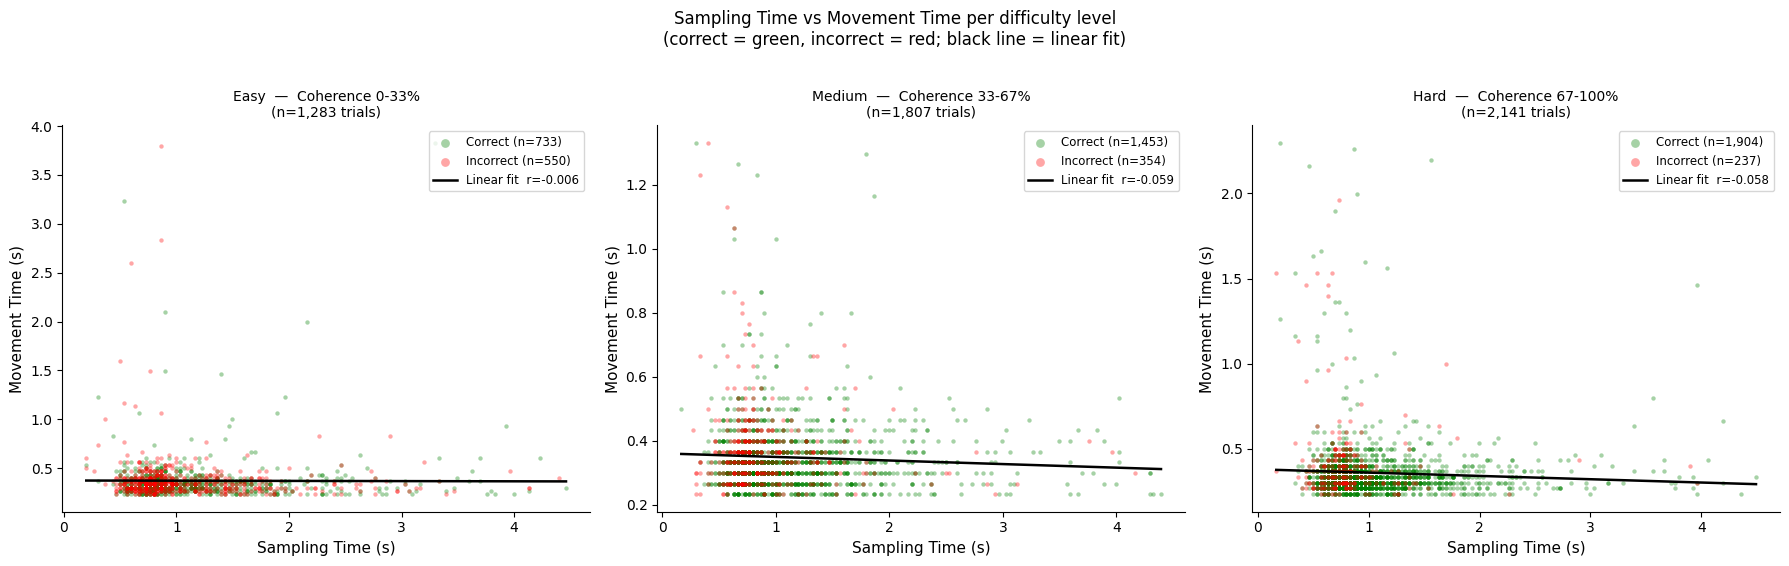

Saved: /sessions/vibrant-confident-cerf/mnt/Fast & Slow/sampling_vs_movement_time.png


In [20]:
# MODIFIED: new behavioral correlation — Sampling Time vs Movement Time per difficulty bin
DIFF_LABELS = ["Easy", "Medium", "Hard"]

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5.5))
for b, ax in enumerate(axes4):
    sub     = mv_trim_c[mv_trim_c.Bin == b].dropna(subset=["SamplingTime", "MT"])
    correct = sub[sub.ChoiceCorrect == 1]
    wrong   = sub[sub.ChoiceCorrect == 0]
    ax.scatter(correct.SamplingTime, correct.MT, c="green", s=10, alpha=0.35,
               linewidths=0, label=f"Correct (n={len(correct):,})")
    ax.scatter(wrong.SamplingTime, wrong.MT, c="red", s=10, alpha=0.35,
               linewidths=0, label=f"Incorrect (n={len(wrong):,})")
    x_all, y_all = sub.SamplingTime.values, sub.MT.values
    if len(x_all) > 1:
        coeffs = np.polyfit(x_all, y_all, 1)
        x_fit  = np.array([x_all.min(), x_all.max()])
        r      = np.corrcoef(x_all, y_all)[0, 1]
        ax.plot(x_fit, np.polyval(coeffs, x_fit), color="black", linewidth=1.8,
                label=f"Linear fit  r={r:.3f}")
    ax.set_xlabel("Sampling Time (s)", fontsize=11)
    ax.set_ylabel("Movement Time (s)", fontsize=11)
    ax.set_title(f"{DIFF_LABELS[b]}  —  Coherence {BIN_LABELS[b]}\n(n={len(sub):,} trials)", fontsize=10)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8.5, loc="upper right", markerscale=2)
fig4.suptitle("Sampling Time vs Movement Time per difficulty level\n"
              "(correct = green, incorrect = red; black line = linear fit)",
              fontsize=12, y=1.02)
fig4.tight_layout()
SCATTER_OUT = HERE / "sampling_vs_movement_time.png"
fig4.savefig(SCATTER_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SCATTER_OUT}")